# Import Libraries

In [ ]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


# Load Dataset

In [ ]:

file_link = 'https://drive.google.com/file/d/1gZo9ucX8xOmdyiyQKx6SIYcBqlvu2S9X/view?usp=sharing'

file_id = file_link.split("/")[-2]
new_link = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(new_link)

print("Dataset loaded successfully.")
print("First five rows:")
display(df.head())

print("Dataset shape:", df.shape)

Dataset loaded successfully.
First five rows:


,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7701354,Azimpur,23.7298,90.3854,2022-08-05T00:00,25.0,16.7,252.0,NaN,18.6,5.2,13.0,50.0
1,7701354,Azimpur,23.7298,90.3854,2022-08-05T01:00,18.5,12.3,249.0,NaN,18.5,5.7,19.0,50.0
2,7701354,Azimpur,23.7298,90.3854,2022-08-05T02:00,16.1,10.9,244.0,NaN,18.4,6.5,27.0,51.0
3,7701354,Azimpur,23.7298,90.3854,2022-08-05T03:00,15.4,10.3,233.0,NaN,17.2,6.9,39.0,51.0
4,7701354,Azimpur,23.7298,90.3854,2022-08-05T04:00,16.8,11.3,217.0,NaN,14.8,6.2,51.0,51.0


Dataset shape: (1048551, 13)


#EDA


## Initial Dataset Inspection

In [ ]:

print("Dataset Information:")
df.info()

print("\nMissing values in each column:")
display(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe())

target_col = "aqi"

print("\nTarget column:", target_col)
print("Data type of target:", df[target_col].dtype)
print("Number of unique AQI values:", df[target_col].nunique())

if df[target_col].dtype == "object" or df[target_col].nunique() <= 10:
    print("This appears to be a Classification Problem.")
else:
    print("This appears to be a Regression Problem.")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048551 entries, 0 to 1048550
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   city_id           1048551 non-null  int64  
 1   city_name         1048551 non-null  object 
 2   lat               1048551 non-null  float64
 3   lon               1048551 non-null  float64
 4   datetime          1048551 non-null  object 
 5   pm10              1048551 non-null  float64
 6   pm2_5             1048551 non-null  float64
 7   carbon_monoxide   1048551 non-null  float64
 8   carbon_dioxide    274224 non-null   float64
 9   nitrogen_dioxide  1048551 non-null  float64
 10  sulphur_dioxide   1048551 non-null  float64
 11  ozone             1048551 non-null  float64
 12  aqi               1047855 non-null  float64
dtypes: float64(10), int64(1), object(2)
memory usage: 104.0+ MB

Missing values in each column:


,0
city_id,0
city_name,0
lat,0
lon,0
datetime,0
pm10,0
pm2_5,0
carbon_monoxide,0
carbon_dioxide,774327
nitrogen_dioxide,0



Number of duplicate rows: 0

Descriptive statistics:


,city_id,lat,lon,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
count,1.048551e+06,1.048551e+06,1.048551e+06,1.048551e+06,1.048551e+06,1.048551e+06,274224.000000,1.048551e+06,1.048551e+06,1.048551e+06,1.047855e+06
mean,1.724447e+06,2.368415e+01,9.048250e+01,7.497350e+01,5.067619e+01,3.235187e+02,456.900698,1.678140e+01,9.784067e+00,7.378080e+01,1.150751e+02
std,1.702309e+06,9.928910e-01,8.652851e-01,6.744548e+01,4.186072e+01,2.804124e+02,20.958356,1.734989e+01,9.302039e+00,4.104232e+01,5.262795e+01
min,1.185100e+06,2.143973e+01,8.863779e+01,2.000000e-01,1.000000e-01,1.000000e-01,408.000000,-1.000000e-01,0.000000e+00,-3.000000e+00,9.000000e+00
25%,1.185241e+06,2.301440e+01,9.006273e+01,2.630000e+01,1.900000e+01,1.550000e+02,444.000000,4.400000e+00,2.900000e+00,4.500000e+01,6.800000e+01
50%,1.185263e+06,2.371040e+01,9.040744e+01,5.610000e+01,3.990000e+01,2.720000e+02,452.000000,1.070000e+01,6.600000e+00,6.400000e+01,1.170000e+02
75%,1.209562e+06,2.407821e+01,9.097640e+01,9.990000e+01,6.960000e+01,4.510000e+02,464.000000,2.440000e+01,1.420000e+01,9.400000e+01,1.572355e+02
max,7.921384e+06,2.567419e+01,9.221946e+01,7.879000e+02,5.513000e+02,5.084000e+03,740.000000,1.780000e+02,1.724000e+02,3.280000e+02,2.995996e+02



Target column: aqi
Data type of target: float64
Number of unique AQI values: 195593
This appears to be a Regression Problem.


##Dataset Overview Table

In [ ]:

dataset_overview = pd.DataFrame({
    "Item": [
        "Dataset Name",
        "Source",
        "File Format",
        "Number of Rows",
        "Number of Columns",
        "Target Variable",
        "Problem Type",
        "Number of Cities"
    ],
    "Description": [
        "Bangladesh Air Quality Dataset",
        "Mendeley Data / Google Drive CSV used in project",
        "CSV",
        df.shape[0],
        df.shape[1],
        "AQI",
        "Regression",
        df["city_name"].nunique()
    ]
})

display(dataset_overview)

,Item,Description
0,Dataset Name,Bangladesh Air Quality Dataset
1,Source,Mendeley Data / Google Drive CSV used in project
2,File Format,CSV
3,Number of Rows,1048551
4,Number of Columns,13
5,Target Variable,AQI
6,Problem Type,Regression
7,Number of Cities,30


## Feature Description Table

In [ ]:


feature_description = pd.DataFrame({
    "Feature": [
        "city_id", "city_name", "lat", "lon", "datetime",
        "pm10", "pm2_5", "carbon_monoxide", "carbon_dioxide",
        "nitrogen_dioxide", "sulphur_dioxide", "ozone", "aqi"
    ],
    "Description": [
        "Unique city/location identifier",
        "Name of the monitoring city or location",
        "Latitude of the monitoring location",
        "Longitude of the monitoring location",
        "Date and time of the observation",
        "Particulate matter with diameter less than 10 micrometers",
        "Fine particulate matter with diameter less than 2.5 micrometers",
        "Carbon monoxide concentration",
        "Carbon dioxide concentration",
        "Nitrogen dioxide concentration",
        "Sulphur dioxide concentration",
        "Ozone concentration",
        "Air Quality Index; target variable"
    ],
    "Role": [
        "Dropped during preprocessing",
        "Input feature after encoding",
        "Dropped during preprocessing",
        "Dropped during preprocessing",
        "Converted into year, month, day, and hour",
        "Input feature",
        "Input feature",
        "Input feature",
        "Dropped due to high missing values",
        "Input feature",
        "Input feature",
        "Input feature",
        "Target variable"
    ]
})

display(feature_description)

,Feature,Description,Role
0,city_id,Unique city/location identifier,Dropped during preprocessing
1,city_name,Name of the monitoring city or location,Input feature after encoding
2,lat,Latitude of the monitoring location,Dropped during preprocessing
3,lon,Longitude of the monitoring location,Dropped during preprocessing
4,datetime,Date and time of the observation,"Converted into year, month, day, and hour"
5,pm10,Particulate matter with diameter less than 10 ...,Input feature
6,pm2_5,Fine particulate matter with diameter less tha...,Input feature
7,carbon_monoxide,Carbon monoxide concentration,Input feature
8,carbon_dioxide,Carbon dioxide concentration,Dropped due to high missing values
9,nitrogen_dioxide,Nitrogen dioxide concentration,Input feature


## Missing Value Analysis

,Feature,Missing Values
8,carbon_dioxide,774327
12,aqi,696
2,lat,0
1,city_name,0
0,city_id,0
4,datetime,0
3,lon,0
6,pm2_5,0
5,pm10,0
7,carbon_monoxide,0


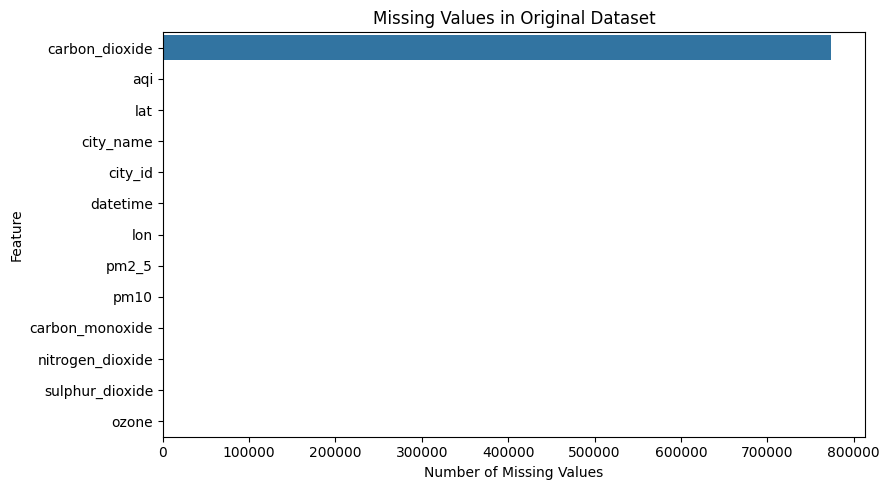

In [ ]:
missing_values = df.isnull().sum().reset_index()
missing_values.columns = ["Feature", "Missing Values"]
missing_values = missing_values.sort_values(by="Missing Values", ascending=False)

display(missing_values)

plt.figure(figsize=(9, 5))
sns.barplot(data=missing_values, x="Missing Values", y="Feature")
plt.title("Missing Values in Original Dataset")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## AQI Distribution Graph

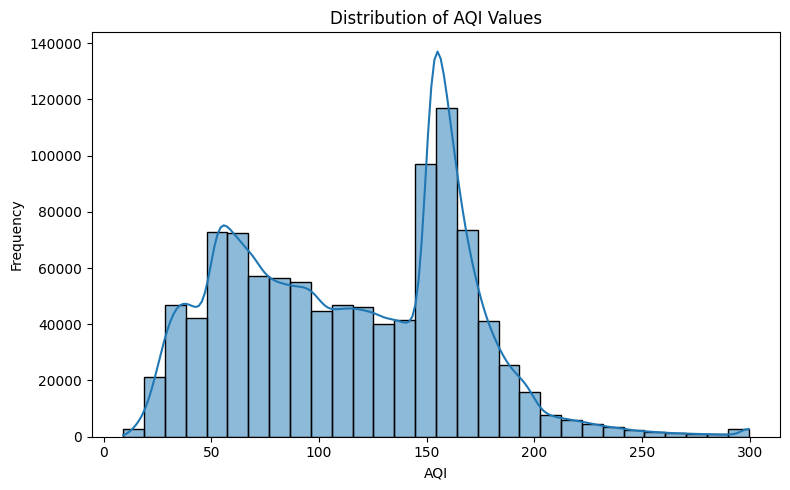

Saved: aqi_distribution.png


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["aqi"], bins=30, kde=True)
plt.title("Distribution of AQI Values")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("aqi_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: aqi_distribution.png")

## Top cities by number of air quality records.

<function matplotlib.pyplot.show(close=None, block=None)>

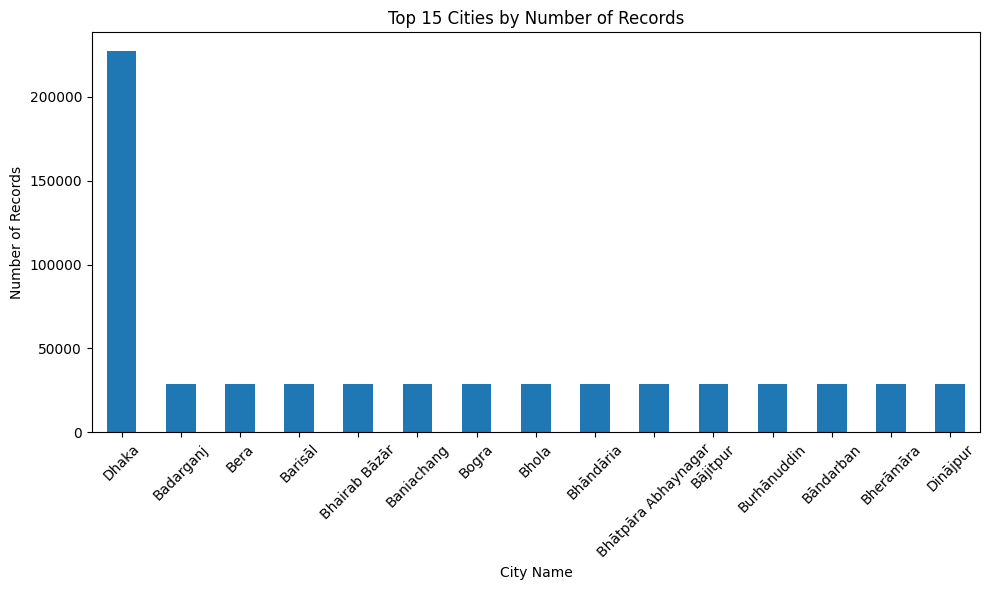

In [ ]:
plt.figure(figsize=(10, 6))
df["city_name"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Cities by Number of Records")
plt.xlabel("City Name")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show

##Feature Classification

In [ ]:
df3 = df
quantitative_data = df3.select_dtypes(include=['int64', 'float64'])
quantitative_features = quantitative_data.columns.tolist()

categorical_data = df3.select_dtypes(include=['object'])
categorical_features = categorical_data.columns.tolist()

print(f"No of Quantitative features {len(quantitative_features)}")
print("Quantitative:", quantitative_features)
print(f"No of Categorical features {len(categorical_features)}")
print("Categorical:", categorical_features)

No of Quantitative features 11
Quantitative: ['city_id', 'lat', 'lon', 'pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aqi']
No of Categorical features 2
Categorical: ['city_name', 'datetime']


## Descriptive statistics for quantitative features

In [ ]:
quantitative_data = df.select_dtypes(include=['int64', 'float64'])
print(quantitative_data.describe())

            city_id           lat           lon          pm10         pm2_5  \
count  1.048551e+06  1.048551e+06  1.048551e+06  1.048551e+06  1.048551e+06   
mean   1.724447e+06  2.368415e+01  9.048250e+01  7.497350e+01  5.067619e+01   
std    1.702309e+06  9.928910e-01  8.652851e-01  6.744548e+01  4.186072e+01   
min    1.185100e+06  2.143973e+01  8.863779e+01  2.000000e-01  1.000000e-01   
25%    1.185241e+06  2.301440e+01  9.006273e+01  2.630000e+01  1.900000e+01   
50%    1.185263e+06  2.371040e+01  9.040744e+01  5.610000e+01  3.990000e+01   
75%    1.209562e+06  2.407821e+01  9.097640e+01  9.990000e+01  6.960000e+01   
max    7.921384e+06  2.567419e+01  9.221946e+01  7.879000e+02  5.513000e+02   

       carbon_monoxide  carbon_dioxide  nitrogen_dioxide  sulphur_dioxide  \
count     1.048551e+06   274224.000000      1.048551e+06     1.048551e+06   
mean      3.235187e+02      456.900698      1.678140e+01     9.784067e+00   
std       2.804124e+02       20.958356      1.734989e+01 

## Visualizations

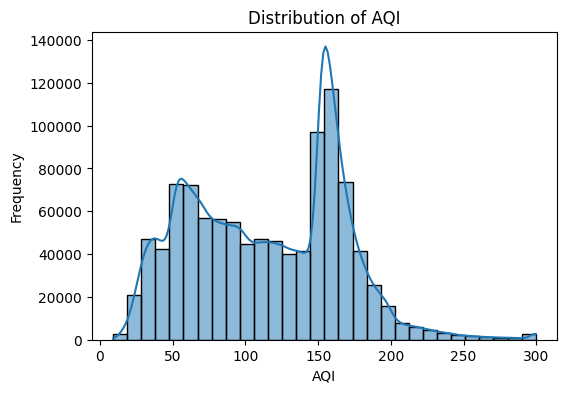

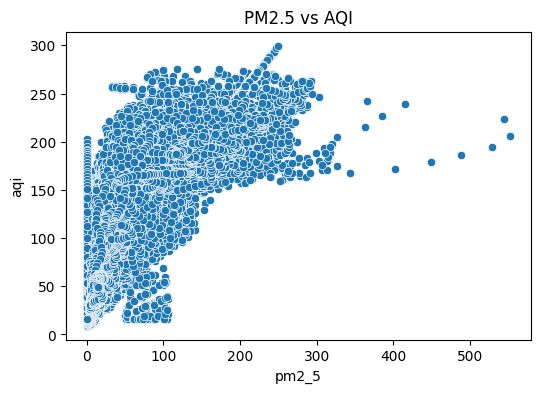

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['aqi'], bins=30, kde=True)
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='pm2_5', y='aqi', data=df)
plt.title("PM2.5 vs AQI")
plt.show()

## Boxplot for AQI

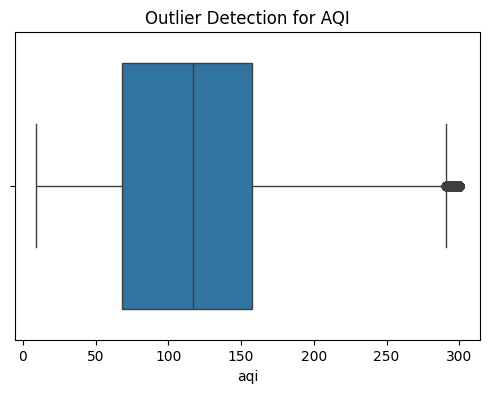

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['aqi'])
plt.title("Outlier Detection for AQI")
plt.show()

## Calculate the correlation matrix

In [ ]:
correlation_matrix = quantitative_data.corr()
correlation_matrix

,city_id,lat,lon,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
city_id,1.000000,0.087334,-0.004818,-0.085050,-0.065647,0.144335,0.004647,0.045517,-0.060070,0.020626,-0.052731
lat,0.087334,1.000000,-0.588738,0.084580,0.108685,0.155091,0.032103,0.103841,0.076109,0.044816,0.160202
lon,-0.004818,-0.588738,1.000000,-0.145511,-0.171617,-0.155433,0.037771,-0.117190,-0.109420,-0.040245,-0.225943
pm10,-0.085050,0.084580,-0.145511,1.000000,0.962252,0.011017,0.434065,0.601537,0.718787,-0.104885,0.838687
pm2_5,-0.065647,0.108685,-0.171617,0.962252,1.000000,0.163968,0.433327,0.610646,0.685722,-0.087849,0.871208
carbon_monoxide,0.144335,0.155091,-0.155433,0.011017,0.163968,1.000000,0.577838,0.211855,-0.086904,0.044467,0.187713
carbon_dioxide,0.004647,0.032103,0.037771,0.434065,0.433327,0.577838,1.000000,0.465274,0.170166,-0.410099,0.266764
nitrogen_dioxide,0.045517,0.103841,-0.117190,0.601537,0.610646,0.211855,0.465274,1.000000,0.589674,-0.428282,0.501582
sulphur_dioxide,-0.060070,0.076109,-0.109420,0.718787,0.685722,-0.086904,0.170166,0.589674,1.000000,-0.076755,0.653967
ozone,0.020626,0.044816,-0.040245,-0.104885,-0.087849,0.044467,-0.410099,-0.428282,-0.076755,1.000000,0.137534


## Correlation Matrix

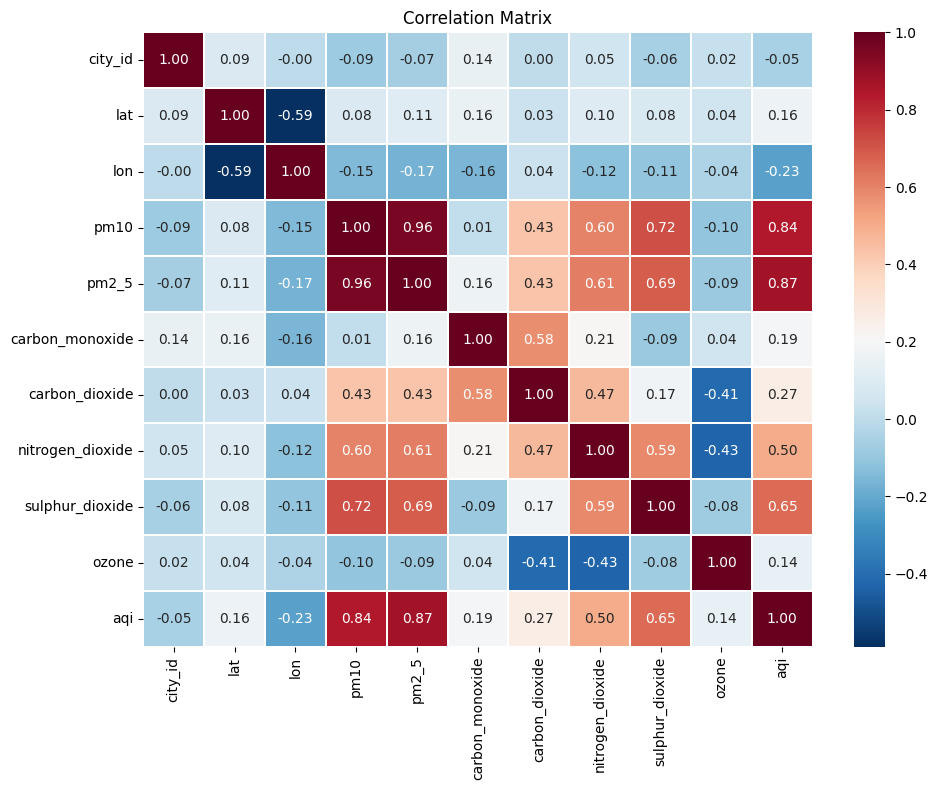

In [ ]:
corr_matrix = quantitative_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.3)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

##Correlation with AQI

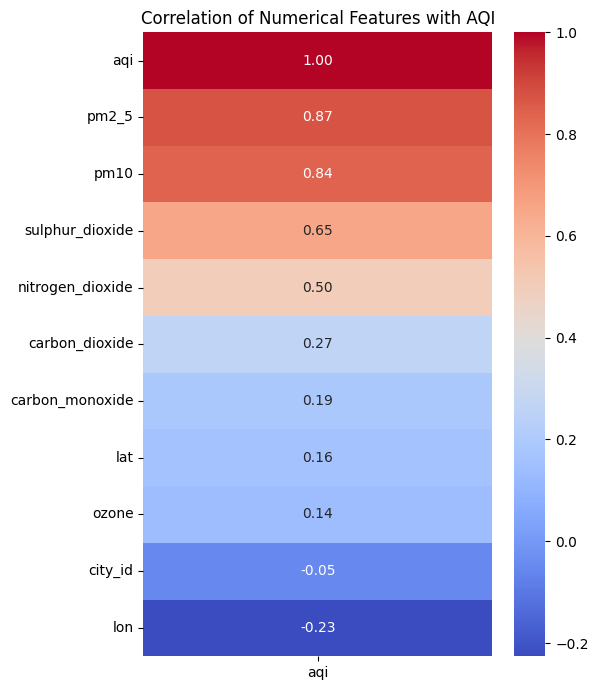

Saved: correlation_aqi.png


In [ ]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr_with_aqi = numeric_df.corr()[["aqi"]].sort_values(by="aqi", ascending=False)

plt.figure(figsize=(6, 7))
sns.heatmap(corr_with_aqi, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Numerical Features with AQI")
plt.tight_layout()

plt.savefig("correlation_aqi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: correlation_aqi.png")

##Distribution of Quantitative Features

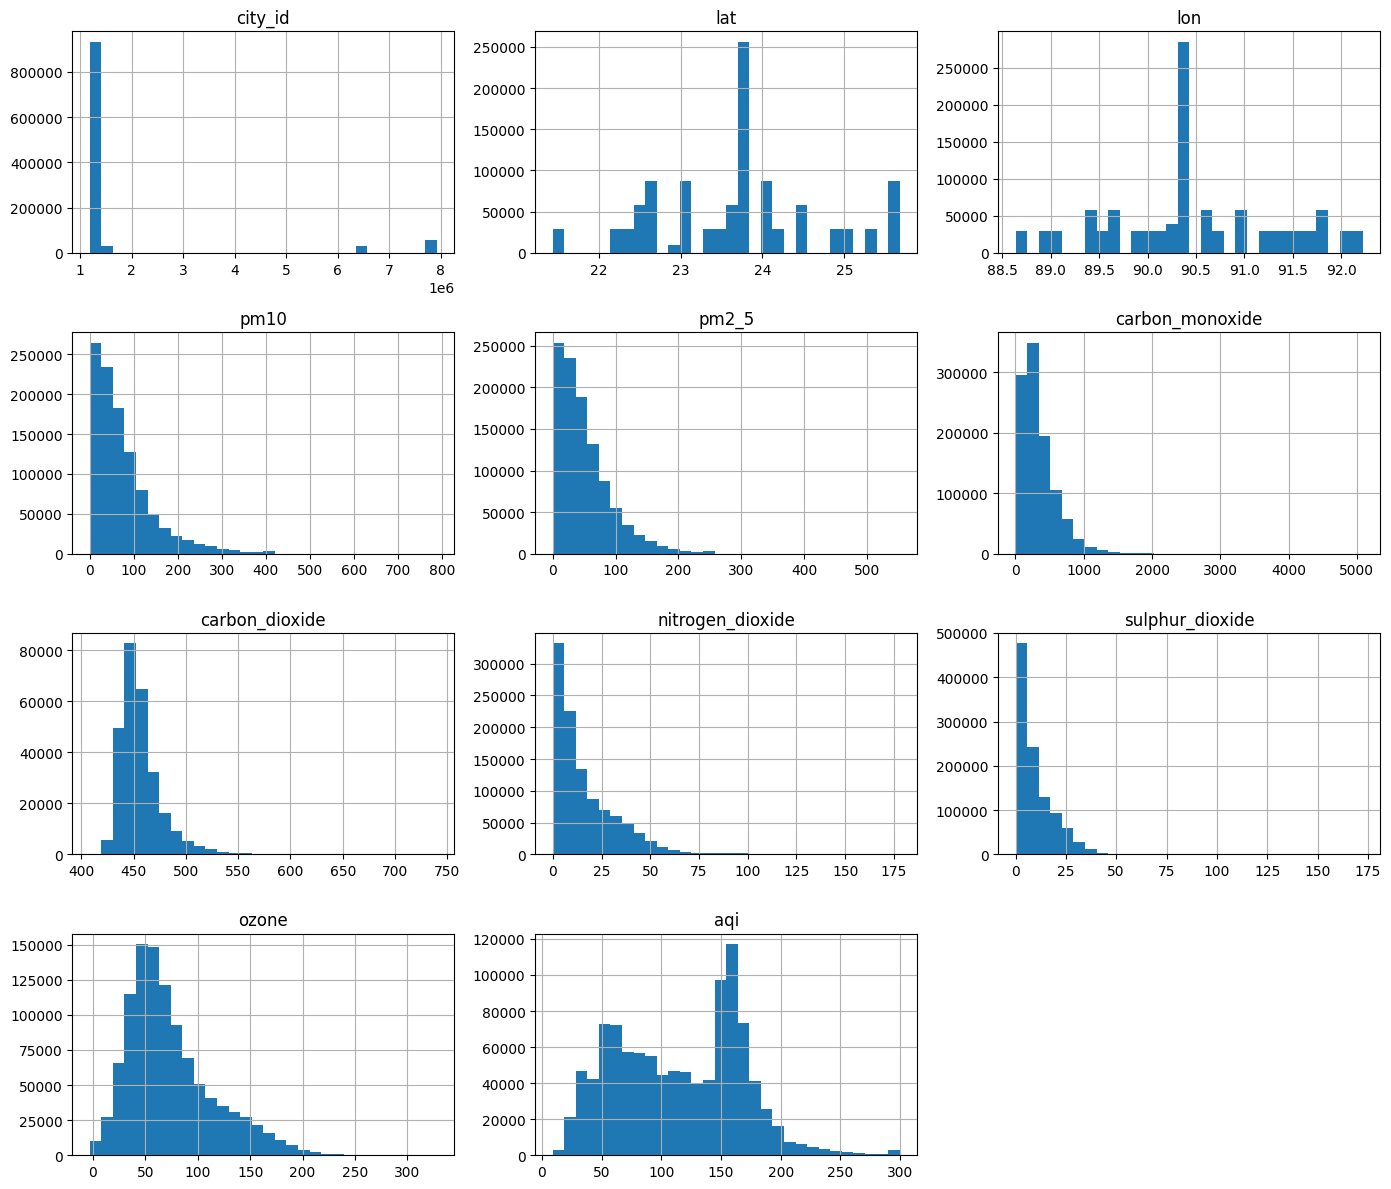

In [ ]:
quantitative_data.hist(figsize=(14,12), bins=30)
plt.tight_layout()
plt.show()

##Density Plot of Numerical Features

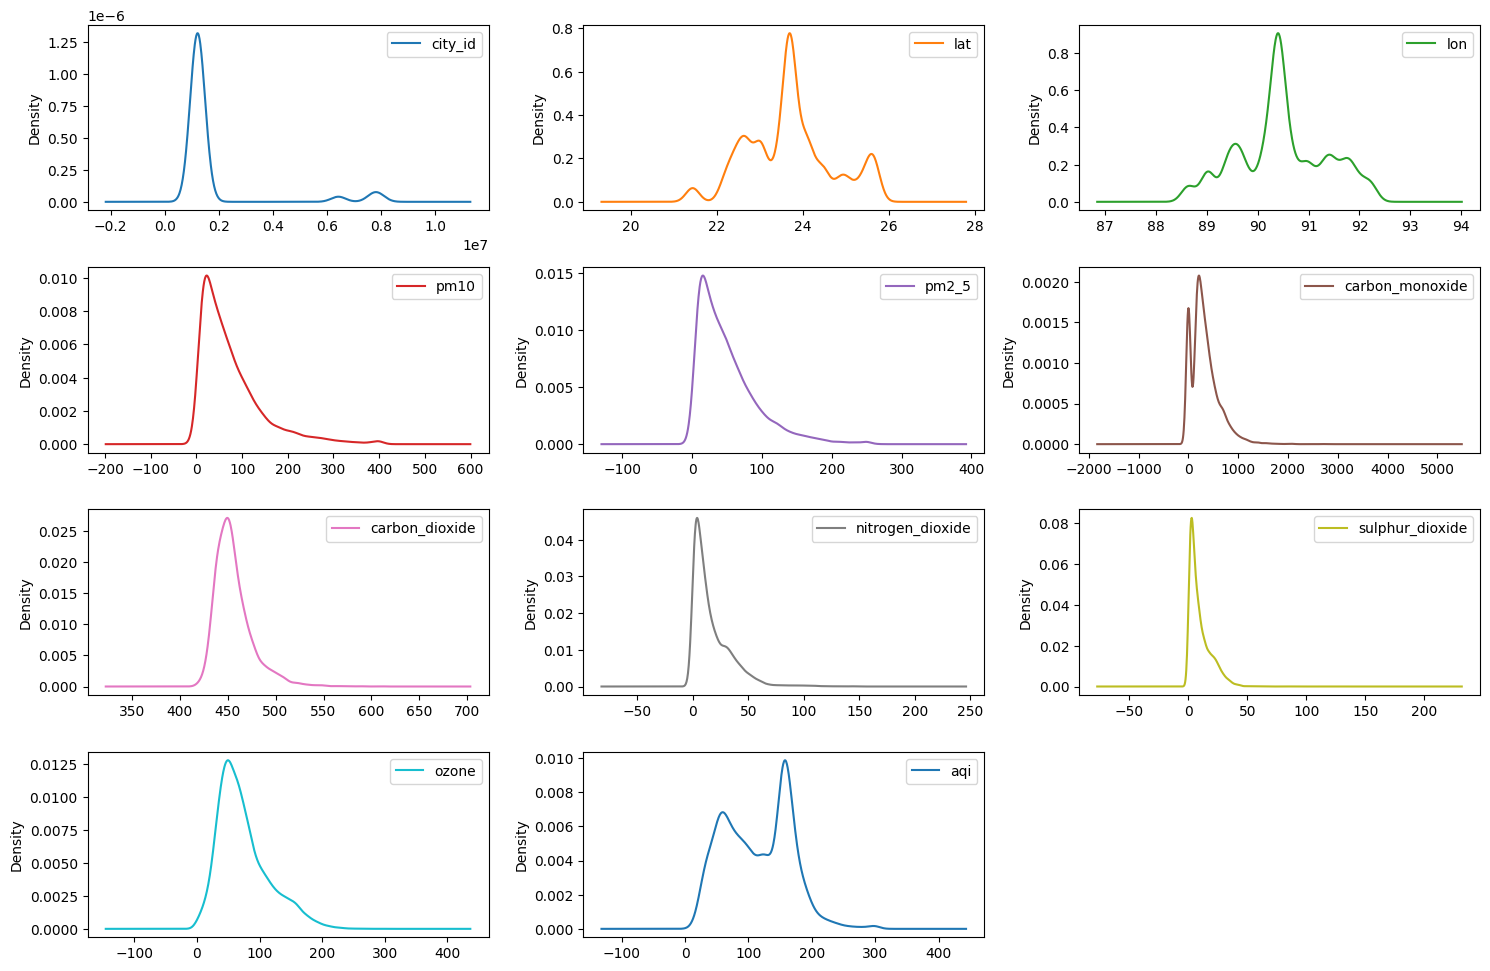

In [ ]:
sample_data = quantitative_data.sample(min(10000, len(quantitative_data)))

sample_data.plot(
    kind='density',
    subplots=True,
    layout=(5,3),
    figsize=(15,12),
    sharex=False
)

plt.tight_layout()
plt.show()

## Boxplot Analysis of Numerical Features

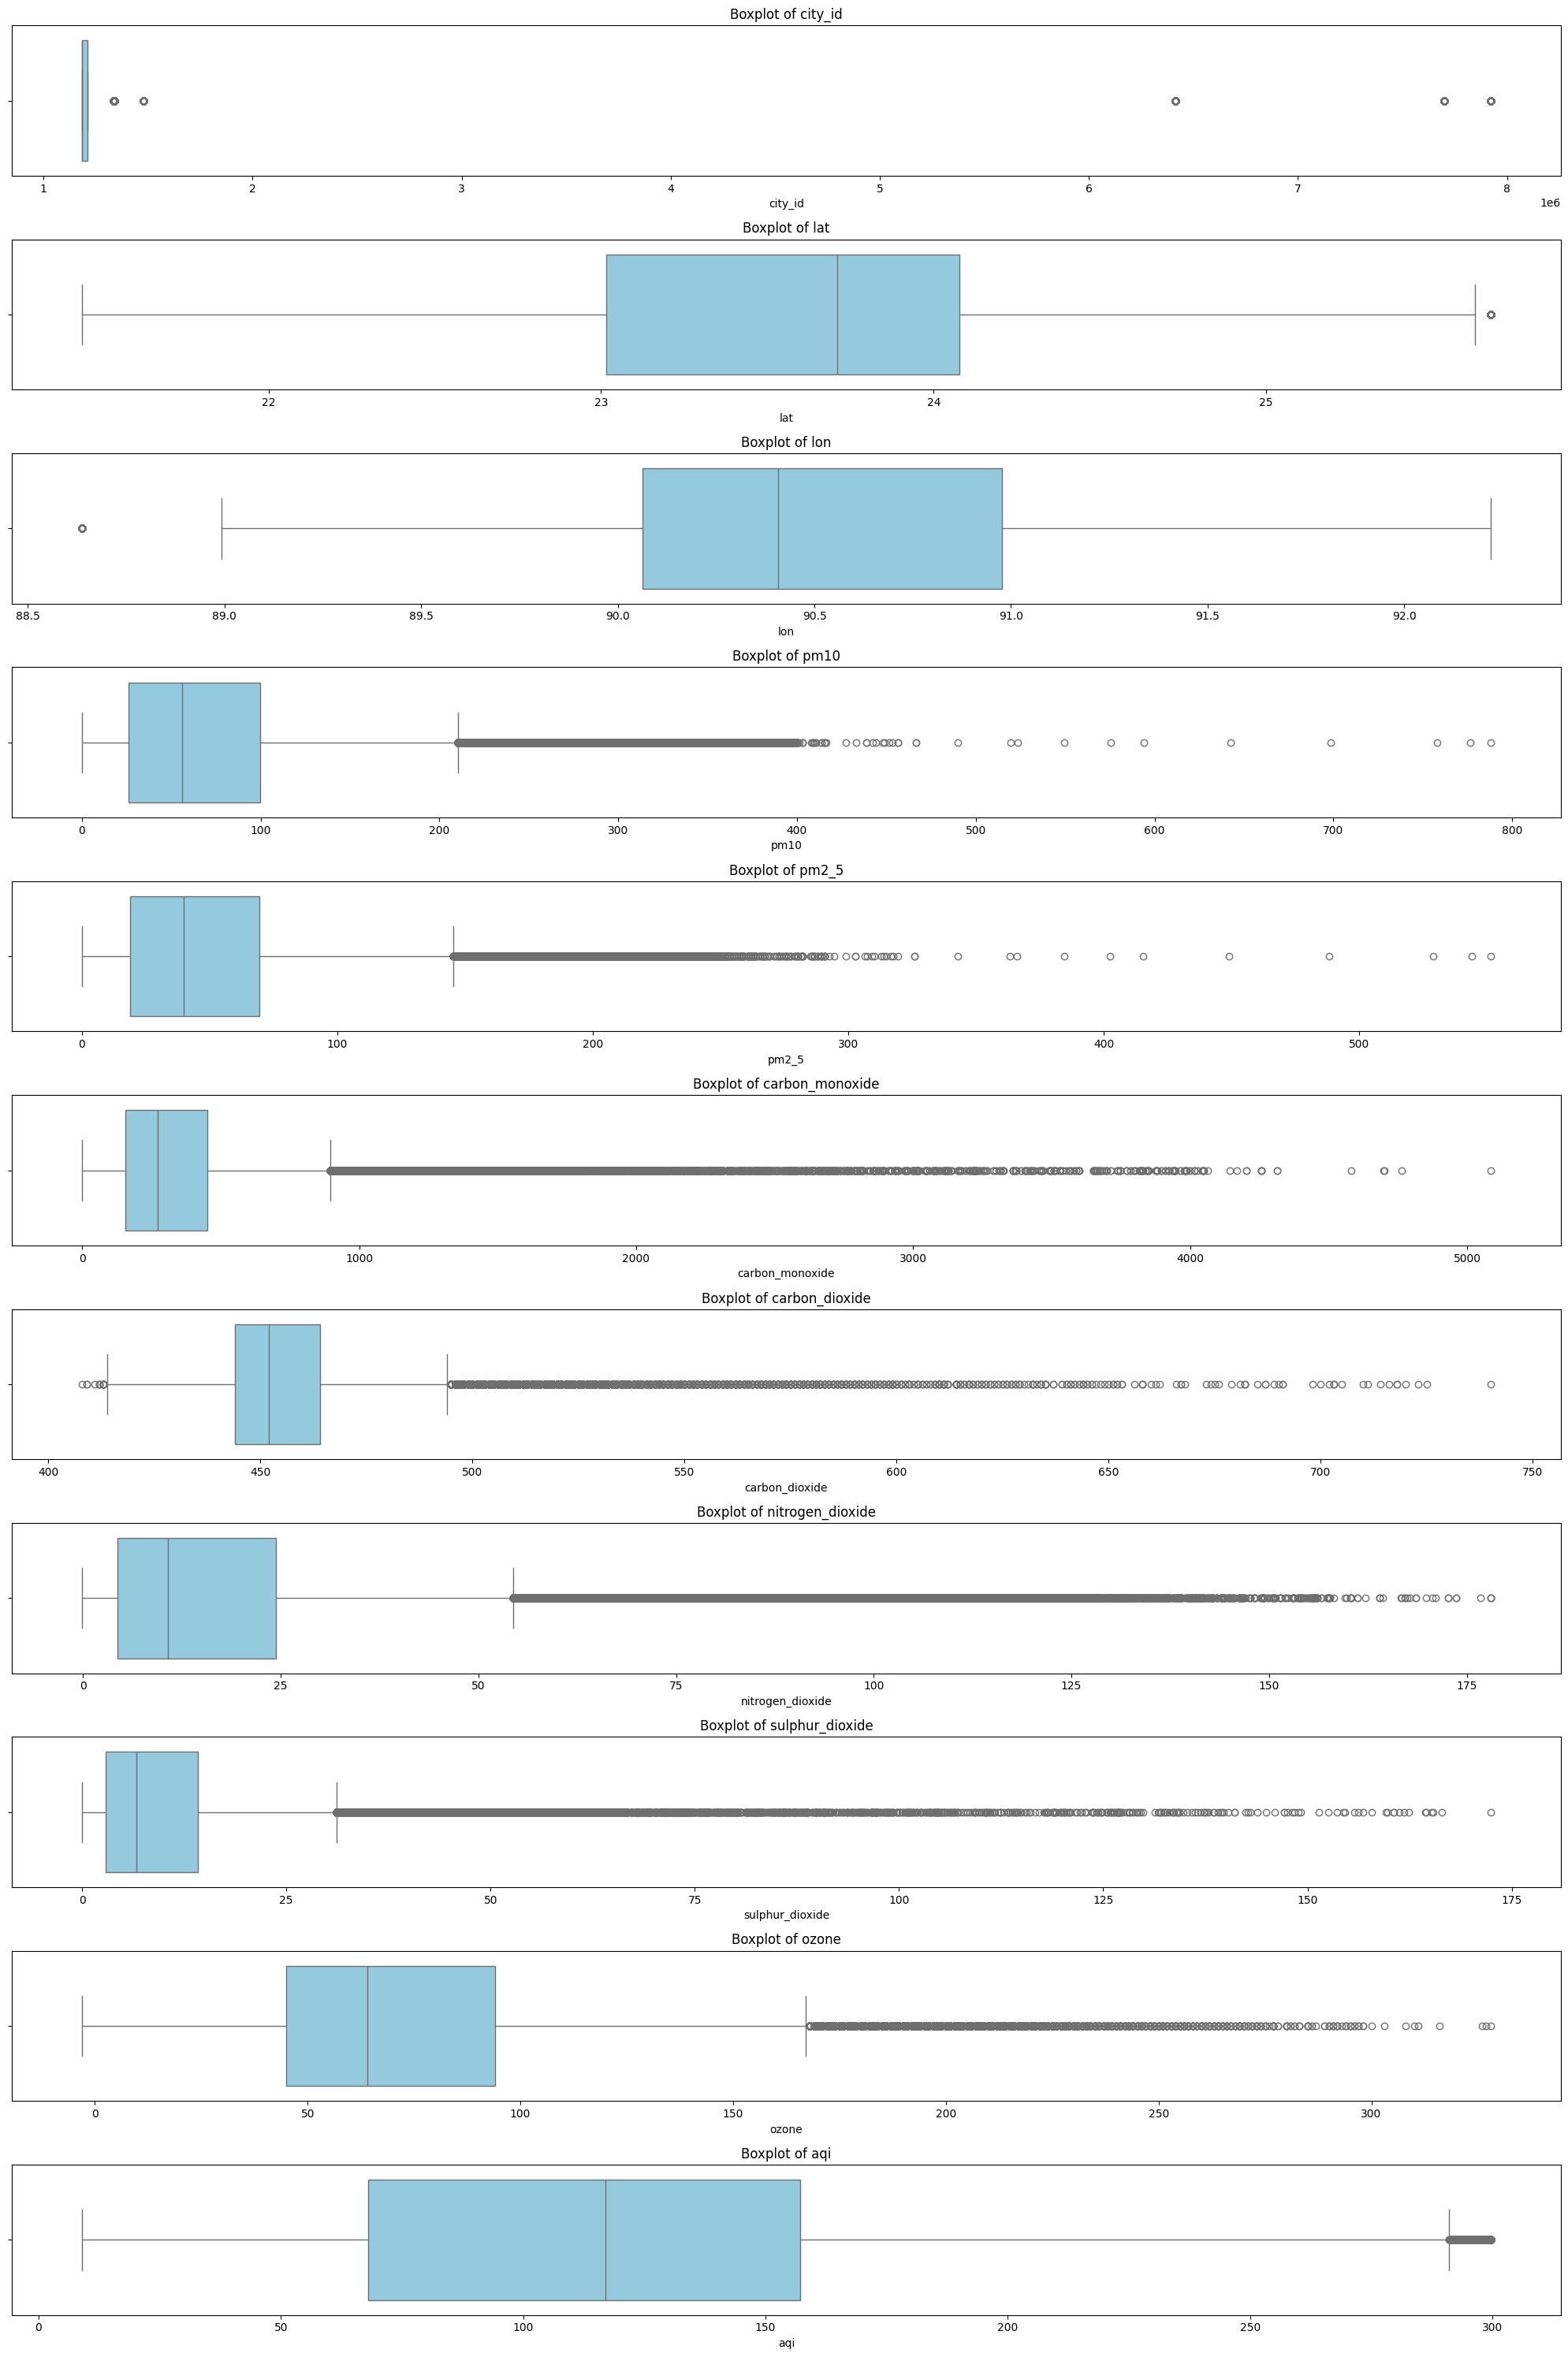

In [ ]:
quantitative_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(20, 30))

for i, col in enumerate(quantitative_cols, 1):
    plt.subplot(len(quantitative_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

In [ ]:
print(quantitative_data.nunique())
print(categorical_data.nunique())

city_id                 30
lat                     30
lon                     30
pm10                194515
pm2_5               196481
carbon_monoxide     200396
carbon_dioxide         276
nitrogen_dioxide    198638
sulphur_dioxide     199057
ozone               198153
aqi                 195593
dtype: int64
city_name        30
datetime     227016
dtype: int64


## Barplot of unique value counts in every categorical features

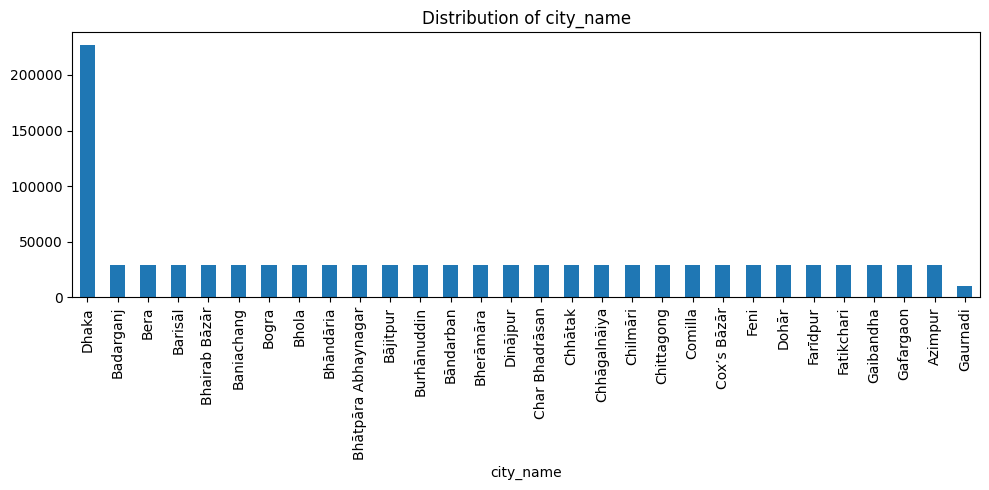

In [ ]:
for col in categorical_features:
    if df[col].nunique() < 50:
        plt.figure(figsize=(10,5))
        df[col].value_counts().plot(kind='bar')
        plt.title(f'Distribution of {col}')
        plt.tight_layout()
        plt.show()

# Data Preprocessing

##Handling

In [ ]:
df2 = df.copy()

# 1. Remove rows where target AQI is missing
df2 = df2.dropna(subset=["aqi"])

# 2. Drop columns with more than 50% missing values
threshold = 0.5
high_null_cols = df2.columns[df2.isnull().mean() > threshold]
df2 = df2.drop(columns=high_null_cols)

print("Dropped high-missing columns:", list(high_null_cols))

# 3. Fill remaining numerical missing values with median
num_cols = df2.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df2[col] = df2[col].fillna(df2[col].median())

# 4. Fill remaining categorical missing values with mode
cat_cols = df2.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

# 5. Drop less useful columns
cols_to_drop = ["city_id", "lat", "lon"]

for col in cols_to_drop:
    if col in df2.columns:
        df2 = df2.drop(columns=col)

# 6. Convert datetime into useful time features
if "datetime" in df2.columns:
    df2["datetime"] = pd.to_datetime(df2["datetime"], errors="coerce")
    df2["year"] = df2["datetime"].dt.year
    df2["month"] = df2["datetime"].dt.month
    df2["day"] = df2["datetime"].dt.day
    df2["hour"] = df2["datetime"].dt.hour
    df2 = df2.drop(columns=["datetime"])

# 7. Encode city_name
if "city_name" in df2.columns:
    le = LabelEncoder()
    df2["city_name"] = le.fit_transform(df2["city_name"])

# 8. Remove outliers using IQR from input features only
outlier_cols = [col for col in df2.select_dtypes(include=["float64", "int64"]).columns if col != "aqi"]

Q1 = df2[outlier_cols].quantile(0.25)
Q3 = df2[outlier_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mask = ~((df2[outlier_cols] < lower_bound) | (df2[outlier_cols] > upper_bound)).any(axis=1)
df2 = df2[mask]

print("Preprocessing completed.")
print("Final shape after preprocessing:", df2.shape)

print("\nMissing values after preprocessing:")
display(df2.isnull().sum())

display(df2.head())

Dropped high-missing columns: ['carbon_dioxide']
Preprocessing completed.
Final shape after preprocessing: (893517, 12)

Missing values after preprocessing:


,0
city_name,0
pm10,0
pm2_5,0
carbon_monoxide,0
nitrogen_dioxide,0
sulphur_dioxide,0
ozone,0
aqi,0
year,0
month,0


,city_name,pm10,pm2_5,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi,year,month,day,hour
0,0,25.0,16.7,252.0,18.6,5.2,13.0,50.0,2022,8,5,0
1,0,18.5,12.3,249.0,18.5,5.7,19.0,50.0,2022,8,5,1
2,0,16.1,10.9,244.0,18.4,6.5,27.0,51.0,2022,8,5,2
3,0,15.4,10.3,233.0,17.2,6.9,39.0,51.0,2022,8,5,3
4,0,16.8,11.3,217.0,14.8,6.2,51.0,51.0,2022,8,5,4


## AQI After Preprocessing

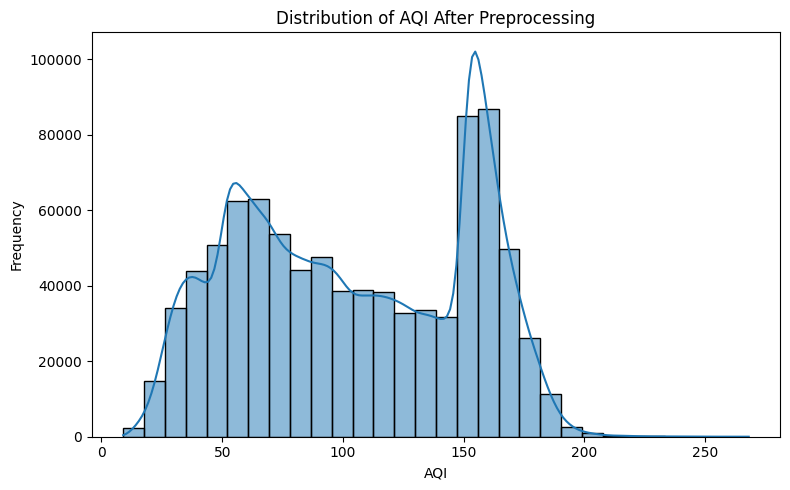

Final row count after preprocessing: 893517
Final feature count including target: 12
Saved: aqi_after_preprocessing.png


In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df2["aqi"], bins=30, kde=True)
plt.title("Distribution of AQI After Preprocessing")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("Final row count after preprocessing:", df2.shape[0])
print("Final feature count including target:", df2.shape[1])

print("Saved: aqi_after_preprocessing.png")

## Final Feature List After Preprocessing

In [ ]:
X = df.drop(columns=['aqi'])
final_feature_summary = pd.DataFrame({
    "No.": range(1, len(X.columns) + 1),
    "Final Input Feature": X.columns
})

display(final_feature_summary)
print("Total final input features:", len(X.columns))
print("Target variable: aqi")

,No.,Final Input Feature
0,1,city_id
1,2,city_name
2,3,lat
3,4,lon
4,5,datetime
5,6,pm10
6,7,pm2_5
7,8,carbon_monoxide
8,9,carbon_dioxide
9,10,nitrogen_dioxide


Total final input features: 12
Target variable: aqi


## Train-Test Split & Scale

In [ ]:

X = df2.drop("aqi", axis=1)
y = df2["aqi"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Input feature shape: (893517, 11)
Target shape: (893517,)
Training shape: (714813, 11)
Testing shape: (178704, 11)
Scaling completed successfully.


# Model

### Evaluation Helper Function

In [ ]:
def evaluate_model(model_name, y_true, y_pred):
    mae = float(mean_absolute_error(y_true, y_pred))
    mse = float(mean_squared_error(y_true, y_pred))
    rmse = float(np.sqrt(mse))
    r2 = float(r2_score(y_true, y_pred))

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R²": r2
    }

##  Baseline Model - Linear Regression

In [ ]:

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

lr_results = evaluate_model("Linear Regression", y_test, y_pred_lr)

# Result
lr_results_df = pd.DataFrame([lr_results])
display(lr_results_df)

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,15.431107,396.410174,19.910052,0.821383


## Decision Tree Regressor

In [ ]:
dt_model = DecisionTreeRegressor(
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

dt_results = evaluate_model("Decision Tree", y_test, y_pred_dt)

# Result
dt_results_df = pd.DataFrame([dt_results])
display(dt_results_df)

,Model,MAE,MSE,RMSE,R²
0,Decision Tree,9.2493,215.219692,14.670368,0.903025


## Random Forest Regressor

In [ ]:

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rf_results = evaluate_model("Random Forest", y_test, y_pred_rf)

# Result
rf_results_df = pd.DataFrame([rf_results])
display(rf_results_df)

,Model,MAE,MSE,RMSE,R²
0,Random Forest,7.123132,125.741248,11.213441,0.943343


## Gradient Boosting Regressor

In [ ]:

gbr_model = GradientBoostingRegressor(
    random_state=42
)

gbr_model.fit(X_train_scaled, y_train)

y_pred_gbr = gbr_model.predict(X_test_scaled)

gbr_results = evaluate_model("Gradient Boosting", y_test, y_pred_gbr)

# Result
gbr_results_df = pd.DataFrame([gbr_results])
display(gbr_results_df)

,Model,MAE,MSE,RMSE,R²
0,Gradient Boosting,10.903762,244.093567,15.623494,0.890015


## Extra Trees Regressor

In [ ]:

et_model = ExtraTreesRegressor(
    n_estimators=50,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

et_model.fit(X_train_scaled, y_train)

y_pred_et = et_model.predict(X_test_scaled)

et_results = evaluate_model("Extra Trees", y_test, y_pred_et)

# Result
et_results_df = pd.DataFrame([et_results])
display(et_results_df)

,Model,MAE,MSE,RMSE,R²
0,Extra Trees,6.825824,115.346753,10.739961,0.948026


## Histogram Gradient Boosting Regressor

In [ ]:

hgb_model = HistGradientBoostingRegressor(
    max_iter=150,
    learning_rate=0.08,
    max_leaf_nodes=31,
    random_state=42
)

hgb_model.fit(X_train_scaled, y_train)

y_pred_hgb = hgb_model.predict(X_test_scaled)

hgb_results = evaluate_model("Histogram Gradient Boosting", y_test, y_pred_hgb)

# Result
hgb_results_df = pd.DataFrame([hgb_results])
display(hgb_results_df)

,Model,MAE,MSE,RMSE,R²
0,Histogram Gradient Boosting,9.497304,187.948385,13.709427,0.915313


## Final Model Comparison

In [ ]:
# ==================================
# Final Model Comparison
# ==================================

results_df = pd.DataFrame([
    lr_results,
    dt_results,
    rf_results,
    gbr_results,
    et_results,
    hgb_results
])

# Sort models by RMSE, lower RMSE is better
results_df = results_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

# Round values for clean table display
results_df_display = results_df.copy()
results_df_display["MAE"] = results_df_display["MAE"].round(6)
results_df_display["MSE"] = results_df_display["MSE"].round(6)
results_df_display["RMSE"] = results_df_display["RMSE"].round(6)
results_df_display["R²"] = results_df_display["R²"].round(6)

print("Final Model Comparison:")
display(results_df_display)

Final Model Comparison:


,Model,MAE,MSE,RMSE,R²
0,Extra Trees,6.825824,115.346753,10.739961,0.948026
1,Random Forest,7.123132,125.741248,11.213441,0.943343
2,Histogram Gradient Boosting,9.497304,187.948385,13.709427,0.915313
3,Decision Tree,9.249300,215.219692,14.670368,0.903025
4,Gradient Boosting,10.903762,244.093567,15.623494,0.890015
5,Linear Regression,15.431107,396.410174,19.910052,0.821383


## Actual vs Predicted AQI Plot - Extra Trees

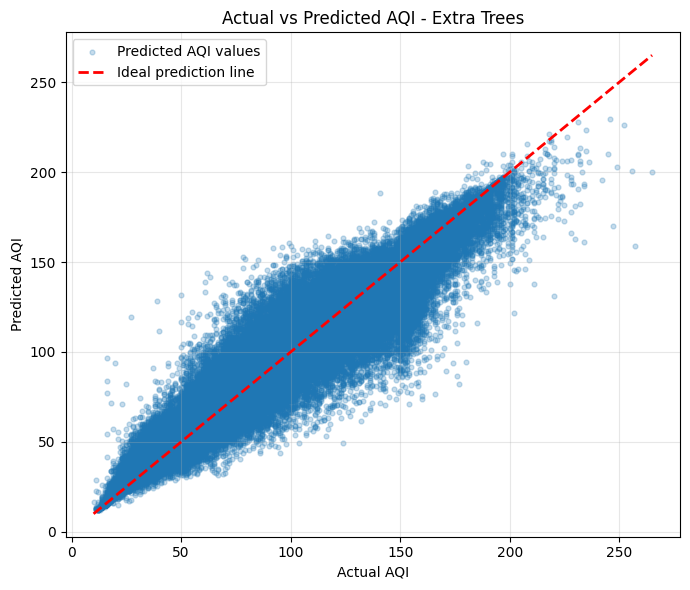

Saved: actual_vs_predicted_et.png


In [ ]:
# =================================================
# Actual vs Predicted AQI Plot - Extra Trees
# =================================================

plt.figure(figsize=(7, 6))

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test,
    y_pred_et,
    alpha=0.25,
    s=12,
    label="Predicted AQI values"
)

# Ideal prediction line
min_val = min(y_test.min(), y_pred_et.min())
max_val = max(y_test.max(), y_pred_et.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Ideal prediction line"
)

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI - Extra Trees")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("actual_vs_predicted_et.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: actual_vs_predicted_et.png")

## RMSE Comparison Graph

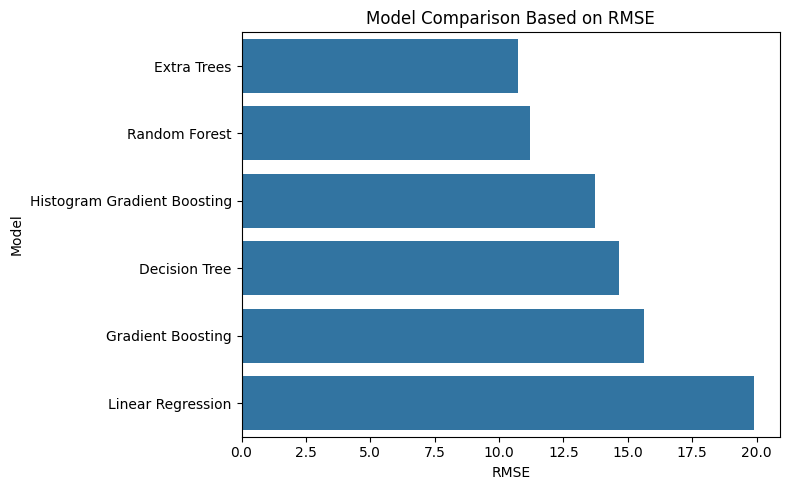

Saved: rmse_comparison.png


In [ ]:

plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="RMSE", y="Model")
plt.title("Model Comparison Based on RMSE")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig("rmse_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: rmse_comparison.png")

## R² Comparison Graph

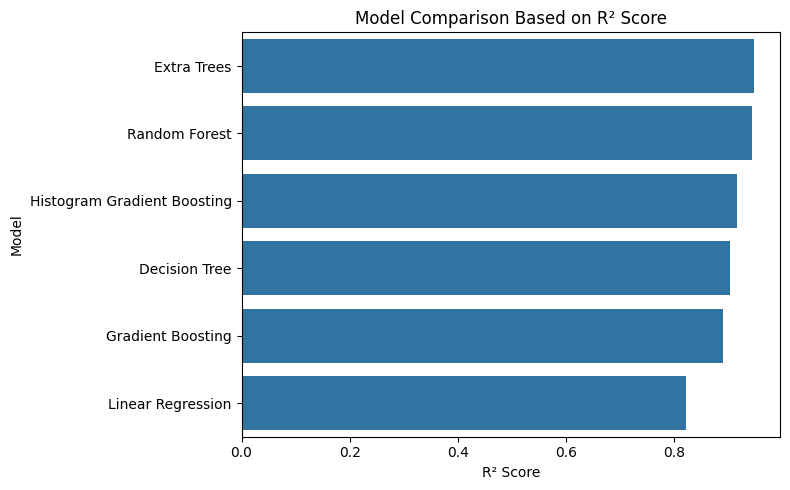

Saved: r2_comparison.png


In [ ]:

plt.figure(figsize=(8, 5))
sns.barplot(
    data=results_df.sort_values(by="R²", ascending=False),
    x="R²",
    y="Model"
)
plt.title("Model Comparison Based on R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig("r2_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: r2_comparison.png")

## Residual Distribution for Best Model

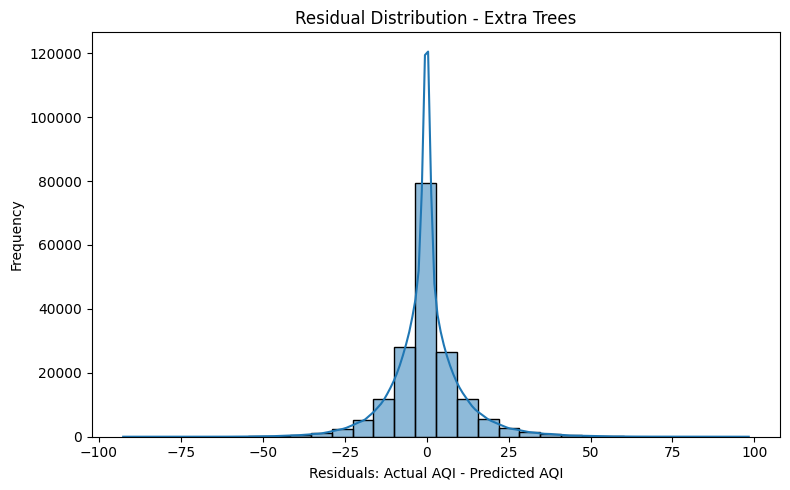

Saved: residual_extra_trees.png


In [ ]:

residuals_et = y_test - y_pred_et

plt.figure(figsize=(8, 5))
sns.histplot(residuals_et, bins=30, kde=True)
plt.title("Residual Distribution - Extra Trees")
plt.xlabel("Residuals: Actual AQI - Predicted AQI")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("residual_extra_trees.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: residual_extra_trees.png")

## Feature Importance Plot

,Feature,Importance
2,pm2_5,0.459662
1,pm10,0.253356
3,carbon_monoxide,0.075932
5,sulphur_dioxide,0.073661
6,ozone,0.044016
8,month,0.026228
9,day,0.017527
4,nitrogen_dioxide,0.014322
10,hour,0.014193
7,year,0.011732


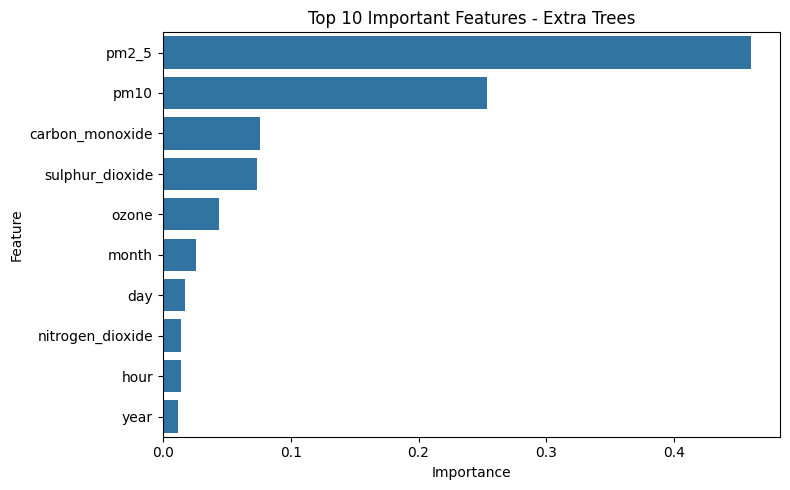

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": et_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance.head(10), x="Importance", y="Feature")
plt.title("Top 10 Important Features - Extra Trees")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Save Processed Dataset and Results

In [ ]:

df2.to_csv("bangladesh_air_quality_preprocessed.csv", index=False)
results_df.to_csv("model_comparison_results.csv", index=False)

print("Saved: bangladesh_air_quality_preprocessed.csv")
print("Saved: model_comparison_results.csv")

Saved: bangladesh_air_quality_preprocessed.csv
Saved: model_comparison_results.csv


#Summary

## Workflow Diagram for IEEE Report

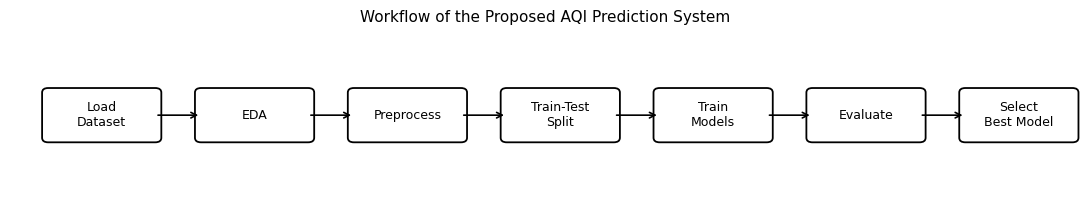

Saved: workflow_diagram.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

steps = [
    "Load\nDataset",
    "EDA",
    "Preprocess",
    "Train-Test\nSplit",
    "Train\nModels",
    "Evaluate",
    "Select\nBest Model"
]

fig, ax = plt.subplots(figsize=(11, 2.2))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis("off")

x_positions = [0.5, 2.5, 4.5, 6.5, 8.5, 10.5, 12.5]

for i, (step, x) in enumerate(zip(steps, x_positions)):
    box = patches.FancyBboxPatch(
        (x, 1.1),
        1.4,
        0.8,
        boxstyle="round,pad=0.08",
        linewidth=1.3,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(x + 0.7, 1.5, step, ha="center", va="center", fontsize=9)

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1], 1.5),
            xytext=(x + 1.4, 1.5),
            arrowprops=dict(arrowstyle="->", linewidth=1.2)
        )

plt.title("Workflow of the Proposed AQI Prediction System", fontsize=11)
plt.tight_layout()
plt.savefig("workflow_diagram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: workflow_diagram.png")

## Train-Test Split Summary

In [ ]:

split_summary = pd.DataFrame({
    "Dataset Part": ["Training Set", "Testing Set"],
    "Rows": [X_train.shape[0], X_test.shape[0]],
    "Features": [X_train.shape[1], X_test.shape[1]],
    "Percentage": ["80%", "20%"]
})

display(split_summary)

,Dataset Part,Rows,Features,Percentage
0,Training Set,714813,11,80%
1,Testing Set,178704,11,20%


## Ranked Model Comparison Table

In [ ]:

ranked_results = results_df.copy()
ranked_results = ranked_results.sort_values(by="RMSE", ascending=True).reset_index(drop=True)
ranked_results.insert(0, "Rank", range(1, len(ranked_results) + 1))

ranked_results_display = ranked_results.copy()
for col in ["MAE", "MSE", "RMSE", "R²"]:
    ranked_results_display[col] = ranked_results_display[col].round(6)

display(ranked_results_display)

,Rank,Model,MAE,MSE,RMSE,R²
0,1,Extra Trees,6.825824,115.346753,10.739961,0.948026
1,2,Random Forest,7.123132,125.741248,11.213441,0.943343
2,3,Histogram Gradient Boosting,9.497304,187.948385,13.709427,0.915313
3,4,Decision Tree,9.249300,215.219692,14.670368,0.903025
4,5,Gradient Boosting,10.903762,244.093567,15.623494,0.890015
5,6,Linear Regression,15.431107,396.410174,19.910052,0.821383


## Improvement of Best Model Over Baseline

In [ ]:

baseline_rmse = results_df[results_df["Model"] == "Linear Regression"]["RMSE"].values[0]
best_rmse = results_df.sort_values(by="RMSE", ascending=True).iloc[0]["RMSE"]
best_model_name = results_df.sort_values(by="RMSE", ascending=True).iloc[0]["Model"]

rmse_improvement = ((baseline_rmse - best_rmse) / baseline_rmse) * 100

baseline_r2 = results_df[results_df["Model"] == "Linear Regression"]["R²"].values[0]
best_r2 = results_df.sort_values(by="RMSE", ascending=True).iloc[0]["R²"]
r2_improvement = ((best_r2 - baseline_r2) / baseline_r2) * 100

improvement_summary = pd.DataFrame({
    "Comparison": [
        "Baseline Model",
        "Best Model",
        "RMSE Improvement Over Baseline",
        "R² Improvement Over Baseline"
    ],
    "Value": [
        "Linear Regression",
        best_model_name,
        f"{rmse_improvement:.2f}%",
        f"{r2_improvement:.2f}%"
    ]
})

display(improvement_summary)

,Comparison,Value
0,Baseline Model,Linear Regression
1,Best Model,Extra Trees
2,RMSE Improvement Over Baseline,46.06%
3,R² Improvement Over Baseline,15.42%


## Feature Importance Values from Extra Trees

In [ ]:
feature_importance_table = pd.DataFrame({
    "Feature": X.columns,
    "Importance": et_model.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

feature_importance_table["Importance"] = feature_importance_table["Importance"].round(6)

display(feature_importance_table)

,Feature,Importance
0,pm2_5,0.459662
1,pm10,0.253356
2,carbon_monoxide,0.075932
3,sulphur_dioxide,0.073661
4,ozone,0.044016
5,month,0.026228
6,day,0.017527
7,nitrogen_dioxide,0.014322
8,hour,0.014193
9,year,0.011732


## Residual Statistics for Extra Trees

In [ ]:

residuals_et = y_test - y_pred_et

residual_summary = pd.DataFrame({
    "Metric": [
        "Mean Residual",
        "Median Residual",
        "Residual Standard Deviation",
        "Minimum Residual",
        "Maximum Residual"
    ],
    "Value": [
        residuals_et.mean(),
        residuals_et.median(),
        residuals_et.std(),
        residuals_et.min(),
        residuals_et.max()
    ]
})

residual_summary["Value"] = residual_summary["Value"].round(6)
display(residual_summary)

,Metric,Value
0,Mean Residual,-0.010636
1,Median Residual,-0.000397
2,Residual Standard Deviation,10.739985
3,Minimum Residual,-92.571667
4,Maximum Residual,98.253333
